In [10]:
%load_ext autoreload
%autoreload 2

from ble import get_ble_controller
from base_ble import LOG
from cmd_types import CMD
import time
import numpy as np
import matplotlib.pyplot as plt

LOG.propagate = False

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
ble = get_ble_controller()
ble.connect()

2026-02-09 14:09:39,854 | INFO     |: Already connected to a BLE device


In [12]:
rx_lines = []

def handle_rx(uuid, value):
    s = value.decode("utf-8").strip()
    rx_lines.append(s)
    print(s)

In [13]:
ble.start_notify(ble.uuid["RX_STRING"], handle_rx)
ble.send_command(CMD.START_RP_LOG, "")

RP_LOG_STARTED
RP_LOG_STOPPED,N=1679


In [14]:
ble.send_command(CMD.DUMP_RP_LOG, "")

t_ms,pitch_deg,roll_deg
0,-0.301,-1.206
2,-0.758,-1.002
4,-0.515,-0.705
7,-0.890,-1.187
9,-0.740,-0.082
11,-0.543,-1.467
18,-0.164,-0.548
20,-0.622,-1.218
22,0.135,-0.378
24,-0.272,-0.626
26,-1.110,-0.703
28,-0.272,-1.033
32,-0.946,-1.027
34,-0.324,-1.107
36,-0.298,-0.923
39,0.845,-0.872
41,6.152,-1.543
43,-1.243,-0.946
46,-0.162,-0.216
48,-1.003,-0.135
50,-2.293,-0.405
55,-3.199,-0.376
57,-4.552,-0.923
59,-1.198,-1.116
64,3.783,-1.893
66,-0.592,-1.130
68,-6.703,0.328
75,0.573,-4.768
77,-4.261,1.006
79,2.165,-0.379
86,2.862,-1.500
88,-2.999,-1.146
95,2.426,-4.173
97,-1.995,0.711
99,2.640,0.871
104,-0.409,-0.491
106,-1.292,0.619
108,2.958,0.814
115,-1.031,-1.980
117,0.298,-0.869
120,-1.993,0.054
122,1.328,-2.141
124,0.596,-1.165
127,0.218,-1.090
129,-1.161,-1.080
131,-0.487,-1.055
138,-0.650,-2.141
140,1.722,0.457
142,0.109,-0.494
144,1.491,-0.704
146,1.358,-0.027
148,-0.244,-0.842
154,-0.459,-1.052
156,-1.023,-1.157
158,-0.571,0.027
165,0.218,-1.146
167,-0.519,-1.611
169,-0.817,-1.498


In [6]:
t_ms_list = []
pitch_list = []
roll_list = []

parsing = False
for s in rx_lines:
    s = s.strip()

    if s.startswith("t_ms,pitch_deg,roll_deg"):
        parsing = True
        continue

    if s.startswith("RP_DUMP_DONE"):
        break

    if parsing:
        parts = s.split(",")
        if len(parts) == 3:
            t_ms_list.append(int(parts[0]))
            pitch_list.append(float(parts[1]))
            roll_list.append(float(parts[2]))

t_ms = np.array(t_ms_list)
pitch = np.array(pitch_list)
roll = np.array(roll_list)

print("Parsed samples:", len(t_ms))
print("t_ms range:", t_ms[0], "->", t_ms[-1])

Parsed samples: 1939
t_ms range: 0 -> 4999


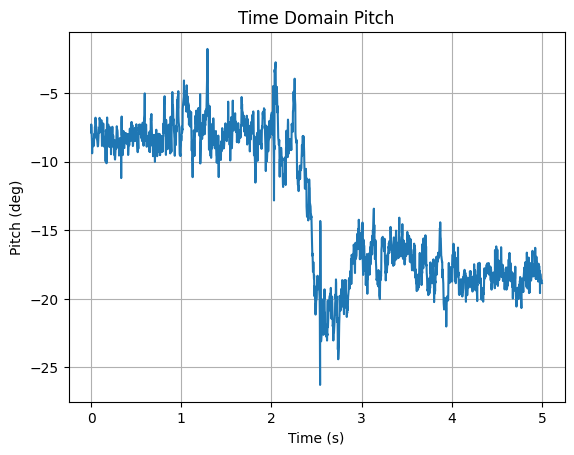

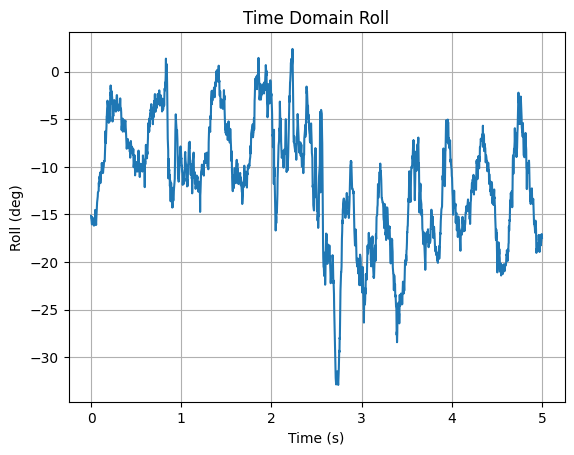

In [7]:
t_s = t_ms / 1000.0  # 转成秒更直观

plt.figure()
plt.plot(t_s, pitch)
plt.xlabel("Time (s)")
plt.ylabel("Pitch (deg)")
plt.title("Time Domain Pitch")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(t_s, roll)
plt.xlabel("Time (s)")
plt.ylabel("Roll (deg)")
plt.title("Time Domain Roll")
plt.grid(True)
plt.show()

sample_rate (Hz) = 499.99999999999955


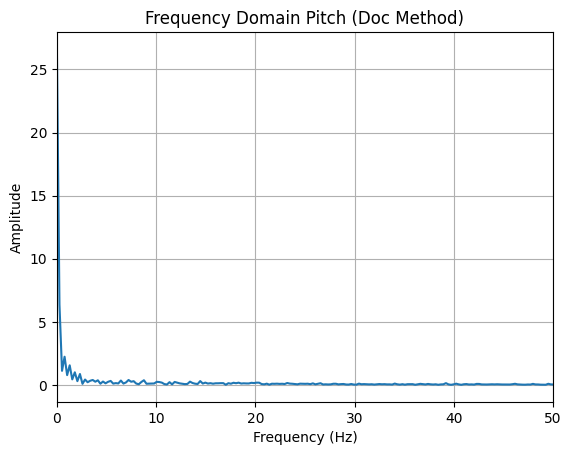

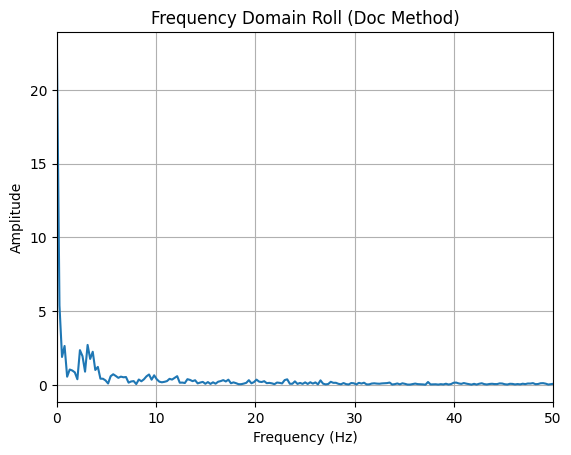

In [8]:
from scipy.fftpack import fft   # 按文档用 scipy.fftpack.fft

# 1) 采样率 sample_rate（按文档叫法）
dt = np.diff(t_s)
sample_rate = 1.0 / np.median(dt)   # samples per second (Hz)
print("sample_rate (Hz) =", sample_rate)

pitch_td = pitch
roll_td  = roll

# 3) N（按文档：数组长度）
N = len(t_s)

# 4) FFT
pitch_fd = fft(pitch_td)
roll_fd  = fft(roll_td)

# 5) 单边幅值谱（按文档：y = 2/N * abs(freq_data[0:int(N/2)])）
half = int(N/2)
pitch_amp = (2.0 / N) * np.abs(pitch_fd[0:half])
roll_amp  = (2.0 / N) * np.abs(roll_fd[0:half])

# 6) 频率轴（按文档：0 到 sample_rate/2）
frequency = np.linspace(0.0, sample_rate/2.0, half, endpoint=False)

# 7) 画图（先看 0~50Hz；想看更细就改小，比如 0~10Hz）
fmax = 50

plt.figure()
plt.plot(frequency, pitch_amp)
plt.xlim(0, fmax)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency Domain Pitch (Doc Method)")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(frequency, roll_amp)
plt.xlim(0, fmax)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency Domain Roll (Doc Method)")
plt.grid(True)
plt.show()

In [9]:
ble.stop_notify(ble.uuid["RX_STRING"])